In [1]:
suppressPackageStartupMessages({
    library(reticulate)
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(lme4)
    library(numDeriv)
    library(dittoSeq)
    library(future)
    library(data.table)
    library(scales)
    plan("multisession", workers = 4)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [2]:
malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
malignant

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [3]:
malignant <- AddMetaData(malignant , readRDS('data//nmf_assigment_malignant_no_core_programs.rds'))

In [4]:
malignant <- subset(malignant, iCNV == 'tumor')
malignant

An object of class Seurat 
19248 features across 258867 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

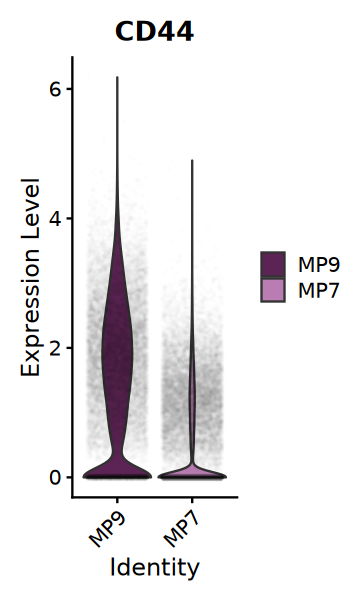

In [45]:
options(repr.plot.height = 5, repr.plot.width = 3)
p <- VlnPlot(malignant, features = 'CD44',idents = c('MP7', 'MP9'),
             cols = c('#5c2454','#ba7db3'),raster=TRUE)
p$layers[[2]]$aes_params$alpha <- 0.008
p

In [46]:
ggsave('figures/vlnplot_CD44.pdf', height = 5, width = 3)

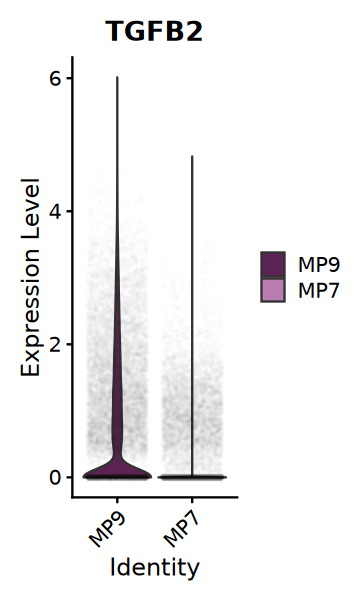

In [47]:
options(repr.plot.height = 5, repr.plot.width = 3)
p <- VlnPlot(malignant, features = 'TGFB2',idents = c('MP7', 'MP9'),
             cols = c('#5c2454','#ba7db3'),raster=TRUE)
p$layers[[2]]$aes_params$alpha <- 0.008
p

In [48]:
ggsave('figures/vlnplot_TGFB2.pdf', height = 5, width = 3)

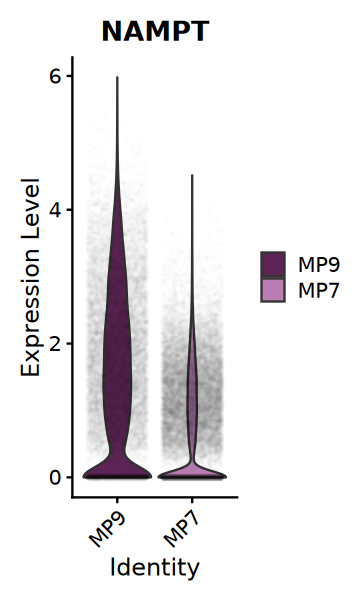

In [49]:
options(repr.plot.height = 5, repr.plot.width = 3)
p <- VlnPlot(malignant, features = 'NAMPT',idents = c('MP7', 'MP9'),
             cols = c('#5c2454','#ba7db3'),raster=TRUE)
p$layers[[2]]$aes_params$alpha <- 0.008
p

In [50]:
ggsave('figures/vlnplot_NAMPT.pdf', height = 5, width = 3)

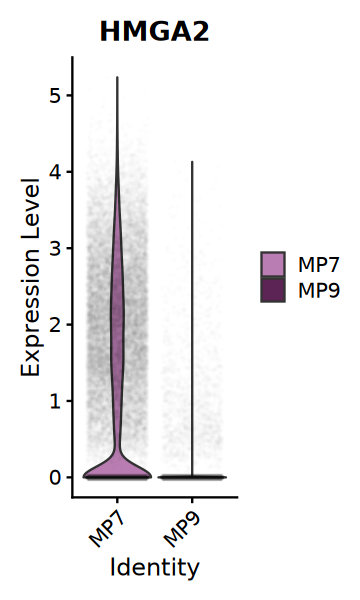

In [52]:
malignant$MP_Assignment <- factor(malignant$MP_Assignment,
                                 levels=c('MP4', 'MP11','MP2',
                            'MP5',
                            'MP3','MP13','MP8',
                            'MP12',
                           'MP7','MP9','unresolved'
                                ))
Idents(malignant) <- malignant$MP_Assignment

options(repr.plot.height = 5, repr.plot.width = 3)
p <- VlnPlot(malignant, features = 'HMGA2',idents = c('MP7', 'MP9'),
             cols = rev(c('#5c2454','#ba7db3')),raster=TRUE)
p$layers[[2]]$aes_params$alpha <- 0.008
p

In [53]:
ggsave('figures/vlnplot_HMGA2.pdf', height = 5, width = 3)

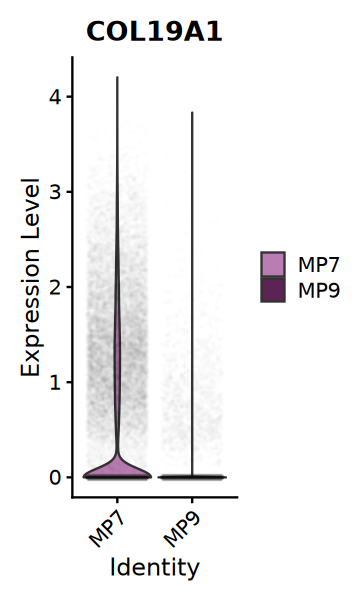

In [59]:
options(repr.plot.height = 5, repr.plot.width = 3)
p <- VlnPlot(malignant, features = 'COL19A1',idents = c('MP7', 'MP9'),
             cols = rev(c('#5c2454','#ba7db3')),raster=TRUE)
p$layers[[2]]$aes_params$alpha <- 0.008
p

In [55]:
ggsave('figures/vlnplot_COL19A1.pdf', height = 5, width = 3)

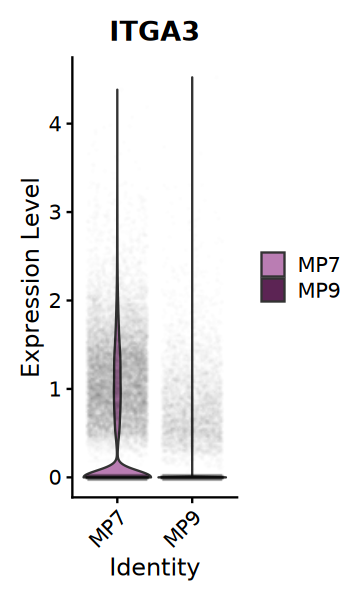

In [56]:
options(repr.plot.height = 5, repr.plot.width = 3)
p <- VlnPlot(malignant, features = 'ITGA3',idents = c('MP7', 'MP9'),
             cols = rev(c('#5c2454','#ba7db3')),raster=TRUE)
p$layers[[2]]$aes_params$alpha <- 0.008
p

In [57]:
ggsave('figures/vlnplot_ITGA3.pdf', height = 5, width = 3)

In [3]:
library(SCpubr)
library(enrichR)

Welcome to enrichR
Checking connection ... 

Enrichr ... 
Connection is Live!

FlyEnrichr ... 
Connection is Live!

WormEnrichr ... 
Connection is Live!

YeastEnrichr ... 
Connection is Live!

FishEnrichr ... 
Connection is Live!

OxEnrichr ... 
Connection is Live!



In [4]:
suppressMessages({
  options(enrichR.base.address = "https://maayanlab.cloud/Enrichr/")
  options(enrichR.live = TRUE)
  options(modEnrichR.use = TRUE)
  options(enrichR.sites.base.address = "https://maayanlab.cloud/")
  options(enrichR.sites = c("Enrichr", "FlyEnrichr", "WormEnrichr", "YeastEnrichr", "FishEnrichr"))

  # Set the search to Human genes.
  enrichR::setEnrichrSite(site = "Enrichr")

  websiteLive <- TRUE
  dbs <- enrichR::listEnrichrDbs()
  # Get all the possible databases to query.
  dbs <- sort(dbs$libraryName)
})


In [7]:
dbs_use <- 'MSigDB_Hallmark_2020'

In [8]:
nmf_modules <- as.data.frame(readRDS('data/robust_NMF_programs_malignant_nomt_noribo.rds'))
nmf_modules

MP_1,MP_2,MP_3,MP_4,MP_5,MP_6,MP_7,MP_8,MP_9,MP_10,MP_11,MP_12,MP_13
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
DIAPH3,CA10,SPARCL1,FTL,BCAS1,VEGFA,GAP43,DNAH6,CD44,HSPH1,SLIT1,KCNH7,CHI3L1
RRM2,MMP16,CLU,FTH1,SIRT2,HILPDA,CAMK2D,MAP3K19,ACTN1,HSPE1,CHD7,SRRM4,GALNT15
TOP2A,PCDH15,DCLK1,EEF1A1,PKP4,SLC6A6,ITGA3,ARMC3,ELL2,USPL1,EGFR,STMN2,NNMT
CENPF,LHFPL3,AQP4,TMSB10,MBP,FAM162A,ADAMTS9,CFAP43,GAP43,CHORDC1,GLCCI1,ELAVL4,ABCA8
ASPM,NXPH1,EEPD1,GAPDH,BMPER,NDRG1,HIVEP3,DNAH9,HRH1,HSPD1,GRIK2,MYT1L,ANXA1
KNL1,SEZ6L,KCNN3,MIF,CDK18,PDK1,EMP1,C6ORF118,LPAR1,DNAJB1,HES6,NYAP2,C3
TPX2,DSCAM,ANOS1,TMSB4X,SHROOM4,INSIG2,GALR1,VWA3A,NAMPT,HSP90AA1,NKD1,RIT2,CP
BRIP1,PDGFRA,SLC4A4,B2M,ST18,SLC2A1,RASSF8,ZBBX,CLIC4,HSP90AB1,PAK3,RND3,MGST1
KIF14,FGF12,DAAM2,PTMA,MYRF,GBE1,RGS17,SPATA17,OSMR,HSPA1A,SEZ6L,CELF4,SPARCL1


In [15]:
genes <- nmf_modules[[7]]

# Retrieve the enriched terms.
enriched_terms <- enrichR::enrichr(genes, dbs_use)
enriched_terms

Uploading data to Enrichr... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.


Term,Overlap,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>
Epithelial Mesenchymal Transition,6/200,0.0000102198,0.000255495,0,0,13.886598,159.573448,TNFRSF12A;IGFBP3;SERPINE1;TNC;SPP1;LAMC1
KRAS Signaling Up,5/200,0.0001398365,0.001747956,0,0,11.256410,99.901053,AKAP12;DNMBP;IGFBP3;SPP1;EMP1
Hypoxia,4/200,0.0015598806,0.012529226,0,0,8.763975,56.642851,AKAP12;ANXA2;IGFBP3;SERPINE1
Androgen Response,3/100,0.0020046761,0.012529226,0,0,13.064049,81.157437,AKAP12;IQGAP2;ELL2
Angiogenesis,2/36,0.0036549257,0.018274629,0,0,24.406863,136.963492,JAG1;SPP1
UV Response Dn,3/144,0.0055948013,0.023311672,0,0,8.967406,46.504228,ANXA2;SERPINE1;LAMC1
Apoptosis,3/161,0.0076080984,0.027171780,0,0,7.995691,39.007314,WEE1;TNFRSF12A;EMP1
TNF-alpha Signaling via NF-kB,3/200,0.0136786260,0.040979218,0,0,6.400151,27.468942,JAG1;SERPINE1;TNC
Cholesterol Homeostasis,2/74,0.0147525185,0.040979218,0,0,11.503472,48.502567,JAG1;TNFRSF12A


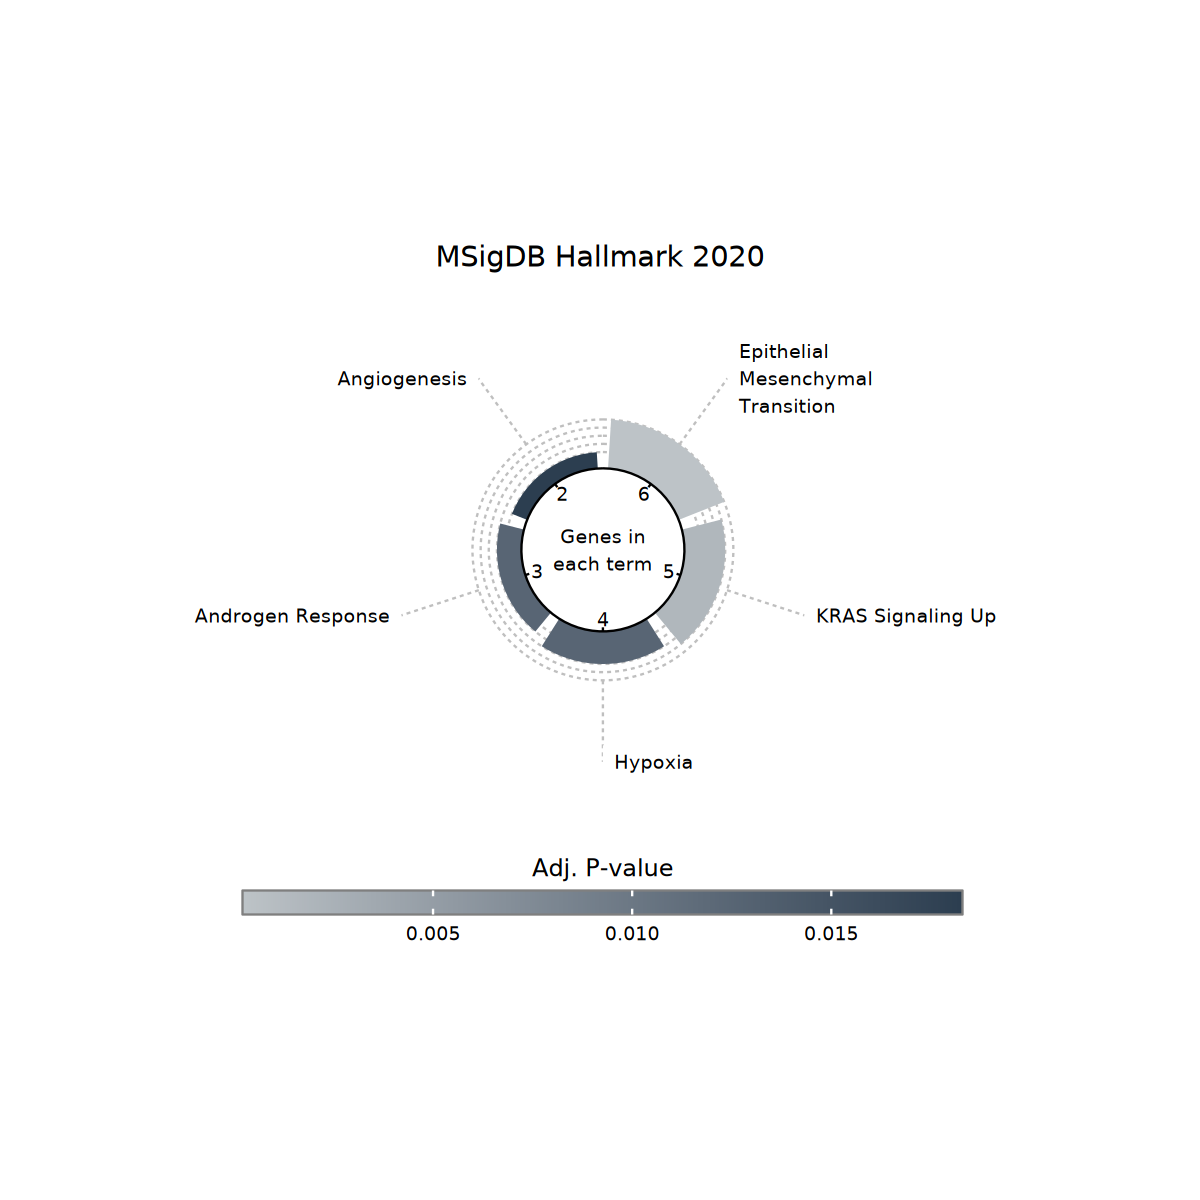

In [17]:
options(repr.plot.height = 10, repr.plot.width = 10)
SCpubr::do_TermEnrichmentPlot(enriched_terms = enriched_terms, nterms = 5)

In [19]:
ggsave('figures/enrichr_hallmarks_MP7.pdf', height = 10, width = 10)

In [20]:
genes <- nmf_modules[[9]]

# Retrieve the enriched terms.
enriched_terms <- enrichR::enrichr(genes, dbs_use)
enriched_terms

Uploading data to Enrichr... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.


Term,Overlap,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>
TNF-alpha Signaling via NF-kB,12/200,6.243396e-14,2.060321e-12,0,0,33.194849,1009.278327,SOCS3;KLF6;PFKFB3;TIPARP;NAMPT;TNC;SOD2;F3;GEM;CD44;ATF3;FOSL2
Hypoxia,6/200,1.021980e-05,1.124178e-04,0,0,13.886598,159.573448,KLF6;PFKFB3;TIPARP;F3;ATF3;FOSL2
Inflammatory Response,6/200,1.021980e-05,1.124178e-04,0,0,13.886598,159.573448,HRH1;KLF6;NAMPT;LPAR1;OSMR;F3
Apoptosis,5/161,5.023041e-05,4.144009e-04,0,0,14.098291,139.557427,TGFB2;EMP1;SOD2;CD44;ATF3
IL-6/JAK/STAT3 Signaling,4/87,6.602363e-05,4.357560e-04,0,0,20.814039,200.345485,SOCS3;OSMR;A2M;CD44
Epithelial Mesenchymal Transition,5/200,1.398365e-04,7.691008e-04,0,0,11.256410,99.901053,COL4A2;COL4A1;TNC;GEM;CD44
IL-2/STAT5 Signaling,4/199,1.531480e-03,5.719562e-03,0,0,8.809365,57.098081,PLSCR1;KLF6;EMP1;CD44
Estrogen Response Early,4/200,1.559881e-03,5.719562e-03,0,0,8.763975,56.642851,UGCG;TIPARP;RETREG1;CD44
Interferon Gamma Response,4/200,1.559881e-03,5.719562e-03,0,0,8.763975,56.642851,SOCS3;PLSCR1;NAMPT;SOD2


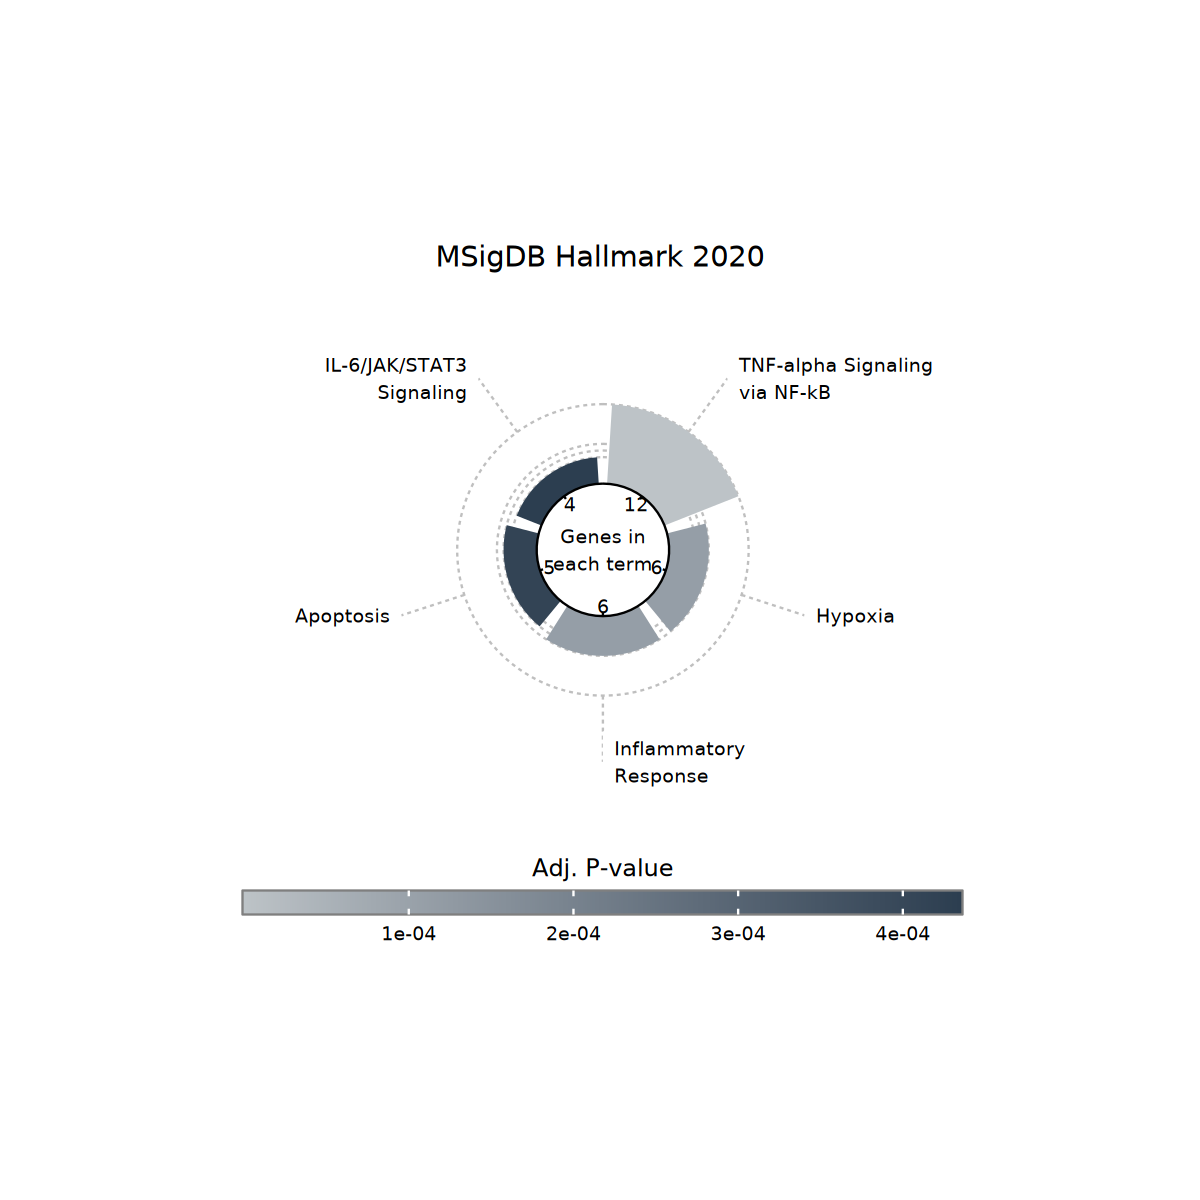

In [22]:
options(repr.plot.height = 10, repr.plot.width = 10)
SCpubr::do_TermEnrichmentPlot(enriched_terms = enriched_terms, nterms = 5)

In [23]:
ggsave('figures/enrichr_hallmarks_MP9.pdf', height = 10, width = 10)

In [4]:
library(zellkonverter)
library(SingleCellExperiment)

Registered S3 method overwritten by 'zellkonverter':
  method                                             from      
  py_to_r.pandas.core.arrays.categorical.Categorical reticulate

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, r

In [5]:
# Replace with your actual path
adata <- readH5AD("/hpc/pmc_stunnenberg/cruiz/scRNA/analysis/gbm/deep_sequencing/references/malignant_core_gbmap.h5ad")

In [6]:
logcounts(adata) <- log1p(assay(adata, "counts"))

In [7]:
gbmap <- as.Seurat(adata, counts = "counts")

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_umap_ to Xumap_”


In [8]:
gbmap

An object of class Seurat 
17346 features across 127528 samples within 1 assay 
Active assay: originalexp (17346 features, 0 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: X_umap

In [ ]:
# Rename the assay from 'originalexp' to 'RNA'
gbmap <- RenameAssays(gbmap, originalexp = "RNA")

In [11]:
malignant <- subset(dmg, lvl_1 == 'Malignant')
malignant

An object of class Seurat 
19248 features across 274318 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [12]:
gbmap$group <- 'Malignant GB'
malignant$group <- 'Malignant DMG'

In [13]:
malignant_all <- merge(gbmap, malignant, merge.data = TRUE)
malignant_all

An object of class Seurat 
19249 features across 401846 samples within 1 assay 
Active assay: RNA (19249 features, 0 variable features)
 2 layers present: counts, data

Warning message:
“
! The following features were not be found:ADAMTS.”


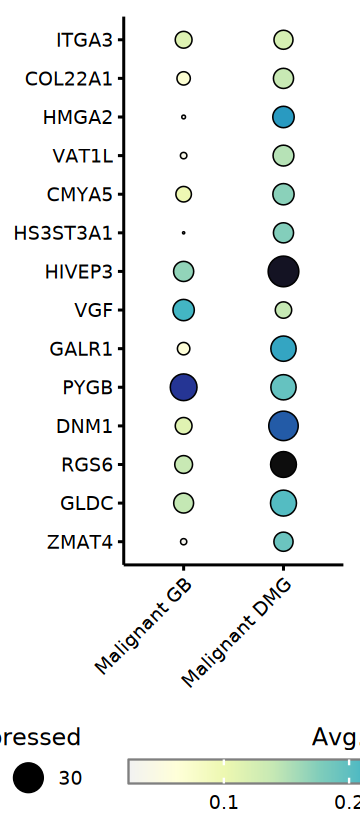

In [16]:
options(repr.plot.height = 7, repr.plot.width = 3)
SCpubr::do_DotPlot(sample = malignant_all,flip = TRUE, group.by = 'group',
                        features = rev(c('ITGA3', 'COL22A1', 'HMGA2', 'VAT1L', 'CMYA5', 'HS3ST3A1', 'HIVEP3', 'VGF', 'ADAMTS', 'GALR1', 'PYGB', 'DNM1', 'RGS6', 'GLDC', 'ZMAT4')), 
                        dot.scale = 8)

In [17]:
ggsave('../figures/pdg_gb_pm_like_marker_genes.pdf', height = 6, width = 2)